In [ ]:
import re
import os
import time
import json
import uuid
import calendar
from dateutil import parser
from dotenv import load_dotenv
from concurrent.futures import ThreadPoolExecutor

import requests
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from scipy.interpolate import RBFInterpolator
from scipy.interpolate import PchipInterpolator
from collections import deque

from api_client import TradingDeskAPI
from options import OptionSurface, Deribit, OKX, Bybit
from scanner import MarketScanner
from portfolio_management import Portfolio

https://alphasignal-dev.moretoncp.com
spot: 63298.0 volume24h: 2.2636
spot: 1884.9 volume24h: 29.8056
spot: 63231.0 volume24h: 5993.62375759
spot: 1879.35 volume24h: 41518.935817
spot: 63231.9 volume24h: 6077.317757
spot: 1879.49 volume24h: 47893.44229
variance min: 0.00025206413975900534
variance max: 0.5067633049891429
T min: 0.0020098418203538925
T max: 0.8616951838860687
negative variance count: 0
zero T count: 0
nan variance count: 0


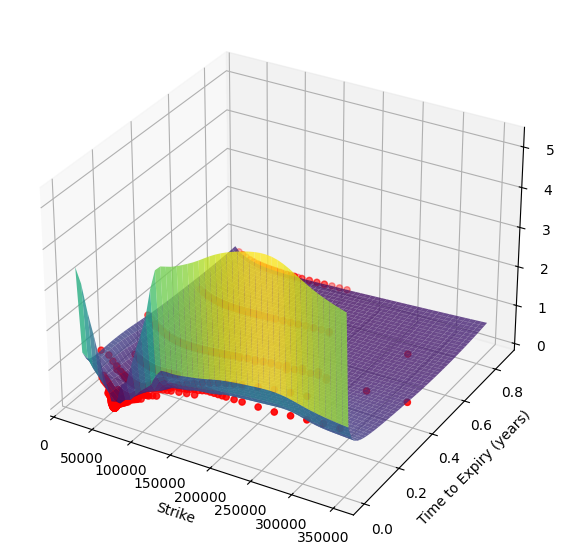

In [ ]:
load_dotenv(r"D:/OneDrive/Trading/Prediction Markets/Moreton Capital/.env")
BASE_URL = os.getenv("BASE_URL")
USER_EMAIL = os.getenv("USER_EMAIL")
USER_PASSWORD = os.getenv("USER_PASSWORD")
JWT_TOKEN = os.getenv("JWT")
print(BASE_URL)

target_expiry_str = "25DEC26"
target_expiry = datetime.strptime(target_expiry_str, "%d%b%y").strftime("%Y%m%d")

currencies = ["BTC", "ETH"]

s = OptionSurface()

deribit = Deribit(currencies=currencies, target_expiry=target_expiry)
okx = OKX(currencies=currencies, target_expiry=target_expiry)
bybit = Bybit(currencies=currencies, target_expiry=target_expiry)

s.initialize(currencies=currencies, exchanges=[deribit, okx, bybit])

In [5]:
api = TradingDeskAPI(base_url=BASE_URL, email=USER_EMAIL, password=USER_PASSWORD, token=JWT_TOKEN)

markets = api.get_markets(limit=10000, liquidity_num_min=10000, volume_num_min=5000)

all_markets_df = pd.DataFrame(markets)

all_markets_df.head()

,id,question,conditionId,slug,resolutionSource,endDate,liquidity,startDate,image,icon,...,oneHourPriceChange,seriesColor,showGmpSeries,showGmpOutcome,umaResolutionStatus,clobRewards,oneMonthPriceChange,gameId,eventStartTime,oneYearPriceChange
0,3246526,Will Viking FK win on 2026-08-14?,0x9fd8ea2a1644e26c732d7a53d8159c78ecf14bdb1acb...,nor-rbk-vik-2026-08-14-vik,https://www.eliteserien.no/,2026-08-14T17:00:00Z,99895.3767,2026-07-31T19:45:14Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3091050,"US x Iran diplomatic meeting by August 15, 2026?",0x7f0d84b155c484b801f2cba68eb0f9ef8b2a0a54b7e6...,us-x-iran-diplomatic-meeting-by-august-15-2026,,2026-08-15T23:59:00Z,99672.40842,2026-07-24T21:54:46.308Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,0.0005,,False,False,NaN,NaN,NaN,NaN,NaN,NaN
2,2747434,Will Hamas agree to disarm by December 31?,0x1e5204036bd51e6ca0e0da6221319c5839bd9940782a...,will-hamas-agree-to-disarm-by-december-31,,2026-12-31T20:00:00Z,99345.8191,2026-06-30T21:17:20.924276Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,-0.0250,,NaN,NaN,disputed,"[{'id': '1101641', 'conditionId': '0x1e5204036...",0.150,NaN,NaN,NaN
3,2771203,Will AC Milan win the 2026-27 Serie A Champion...,0xf6ecbdccc8c5139875da5ac5df461cf5d8c12abe2776...,will-ac-milan-win-the-2026-27-serie-a-champion...,,2027-05-30T23:59:00Z,99213.1052,2026-07-02T18:01:49.820972Z,NaN,NaN,...,NaN,NaN,False,False,NaN,"[{'id': '762945', 'conditionId': '0xf6ecbdccc8...",-0.010,NaN,NaN,NaN
4,630806,Will the Republicans win the Michigan Senate r...,0x3fd189cac9280dfc49a07115581e8d4c9e0b7e1c1e85...,will-the-republicans-win-the-michigan-senate-r...,NaN,NaN,99197.348,2025-10-13T21:45:17.492648Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,NaN,False,False,NaN,"[{'id': '38089', 'conditionId': '0x3fd189cac92...",0.165,NaN,NaN,NaN


In [59]:
api = TradingDeskAPI(base_url=BASE_URL, email=USER_EMAIL, password=USER_PASSWORD, token=JWT_TOKEN)
markets1 = api.list_markets(limit=500)
all_markets_df1 = pd.DataFrame(markets1)

all_markets_df1["liquidityNum"] = pd.to_numeric(all_markets_df1["liquidityNum"], errors="coerce")
all_markets_df1["volumeNum"] = pd.to_numeric(all_markets_df1["volumeNum"], errors="coerce")

all_markets_df1 = all_markets_df1[(all_markets_df1["liquidityNum"] >= 10000) & (all_markets_df1["volumeNum"] >= 5000)]
all_markets_df1 = all_markets_df1.sort_values("liquidityNum", ascending=False).reset_index(drop=True)

all_markets_df1.head()

,id,question,conditionId,slug,resolutionSource,endDate,liquidity,startDate,image,icon,...,makerBaseFee,takerBaseFee,gameId,sportsMarketType,eventStartTime,feeSchedule,oneHourPriceChange,clobRewards,oneYearPriceChange,marketMetadata
0,561249,Will Greg Abbott win the 2028 US Presidential ...,0x01dffa7abae7e5d9b7fb44b06d537c5ac932e2ca422a...,will-greg-abbott-win-the-2028-us-presidential-...,,2028-11-07T00:00:00Z,2290255.79328,2025-07-11T19:06:08.361Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,1000.0,1000.0,NaN,NaN,NaN,"{'exponent': 1, 'rate': 0.04, 'takerOnly': Tru...",NaN,NaN,0.005,NaN
1,559665,Will Cory Booker win the 2028 Democratic presi...,0x1970bcce75e3674660917ae4685b433a9b1e0152d810...,will-corey-booker-win-the-2028-democratic-pres...,,2028-11-07T00:00:00Z,2018415.08907,2025-07-11T18:36:10.848Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,1000.0,1000.0,NaN,NaN,NaN,"{'exponent': 1, 'rate': 0.04, 'takerOnly': Tru...",NaN,NaN,-0.008,NaN
2,3128885,Strait of Hormuz traffic returns to normal by ...,0x49479ffa88e2897569b1d413e3bc558003e21912edee...,strait-of-hormuz-traffic-returns-to-normal-by-...,,2026-08-15T00:00:00Z,1851330.89078,2026-07-27T17:50:28.17351Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2252246,Will the Fed increase interest rates by 50+ bp...,0x2e4b58fc18dbffd74d5275d89fb076943f21992763c4...,will-the-fed-increase-interest-rates-by-50-bps...,NaN,2026-09-16T00:00:00Z,1014072.16326,2026-05-13T21:23:16.501737Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,1000.0,1000.0,NaN,NaN,NaN,"{'exponent': 1, 'rate': 0.05, 'takerOnly': Tru...",NaN,NaN,NaN,NaN
4,3563239,Dota 2: Team Yandex vs Team Liquid (BO3) - The...,0x3b7971cd72e15ff80e623a7521fa3e0545b296545792...,dota2-ty-liquid-2026-08-13,https://www.dotabuff.com,2026-08-14T08:00:00Z,786995.05327,2026-08-13T11:19:35Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,1000.0,1000.0,1633343,moneyline,2026-08-14T02:00:00Z,"{'exponent': 1, 'rate': 0.05, 'takerOnly': Tru...",NaN,NaN,NaN,NaN


In [60]:
BTC_KEYWORDS = [
    "bitcoin",
    "btc",
    "xbt"
]

ETH_KEYWORDS = [
    "ethereum",
    " eth "
]

KEYWORDS = [
    "bitcoin",
    "btc",
    "xbt",
    "ethereum",
    " eth "
]

scanner = MarketScanner(api=api, BASE_URL=BASE_URL, USER_EMAIL=USER_EMAIL, USER_PASSWORD=USER_PASSWORD)
markets_df, opportunities_df = scanner.scan_market(markets_df=all_markets_df, s=s, KEYWORDS=KEYWORDS)

opportunities_df

iv 0.4911040328616745
p_touch_above: 1.0 p_touch_below: 0.29559

BTC
buy_yes_ev: 0.03246500000000002
sell_yes_ev: -0.06835800000000003
buy_no_ev: -0.06835800000000003
sell_no_ev: 0.032464999999999966
buy_yes_kelly: 0.022028837998303664
sell_yes_kelly: -0.1504145542881285
buy_no_kelly: -0.1504145542881285
sell_no_kelly: 0.022028837998303626
iv 0.4858659340631817
p_touch_above: 0.00368 p_touch_below: 1.0

BTC
buy_yes_ev: -0.0005988800000000004
sell_yes_ev: -0.00088937
buy_no_ev: -0.000889369999999984
sell_no_ev: -0.0005988799999999848
buy_yes_kelly: -0.0003007267737777825
sell_yes_kelly: -0.15934932255440526
buy_no_kelly: -0.15934932255440148
sell_no_kelly: -0.0003007267737777746
iv 0.5675172417628929
p_touch_above: 1.0 p_touch_below: 0.01993

BTC
buy_yes_ev: 0.004963720000000001
sell_yes_ev: -0.007828169999999999
buy_no_ev: -0.007828170000000018
sell_no_ev: 0.004963720000000003
buy_yes_kelly: 0.0025195685686780355
sell_yes_kelly: -0.32342918385070685
buy_no_kelly: -0.3234291838507081
se

,id,question,conditionId,slug,resolutionSource,endDate,liquidity,startDate,image,icon,...,buy_yes_ev,sell_yes_ev,buy_no_ev,sell_no_ev,buy_yes_kelly,sell_yes_kelly,buy_no_kelly,sell_no_kelly,best_ev,best_action
14,701502,"Will Bitcoin dip to $45,000 by December 31, 2026?",0x024b68f77bfc019341ee3db8f57c103334e4b9430bba...,will-bitcoin-dip-to-45000-by-december-31-2026-...,,2027-01-01T05:00:00Z,98098.2908,2025-11-24T19:07:15.386Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,0.032465,-0.068358,-0.068358,0.032465,0.022029,-0.150415,-0.150415,0.022029,0.032465,buy_yes_ev
56,701486,"Will Bitcoin reach $200,000 by December 31, 2026?",0xac32e73aa9e0dae801d88d4f81efd2ef3fa0f04b815f...,will-bitcoin-reach-200000-by-december-31-2026-...,,2027-01-01T05:00:00Z,92164.52532,2025-11-24T19:07:20.933Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,-0.020622,0.016945,0.016945,-0.020622,-0.010536,0.478808,0.478808,-0.010536,0.016945,buy_no_ev
44,1343228,"Will Bitcoin dip to $5,000 by December 31, 2026?",0xe681a6326237f3b17ce8622728b6cd104281dfe4d2b3...,will-bitcoin-dip-to-5000-by-december-31-2026-j...,,2027-01-01T05:00:00Z,94380.77619,2026-02-05T22:18:33.034Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,-0.020305,0.015830,0.015830,-0.020305,-0.010363,0.500000,0.500000,-0.010363,0.015830,buy_no_ev
78,701554,"Will Ethereum dip to $800 by December 31, 2026?",0x717672a48c5f2938631f6e467b9a48aedb03fa380c01...,will-ethereum-dip-to-800-by-december-31-2026-568,,2027-01-01T05:00:00Z,89893.7807,2025-11-24T19:27:14.172Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,0.010978,-0.030687,-0.030687,0.010978,0.006000,-0.234456,-0.234456,0.006000,0.010978,buy_yes_ev
29,3257364,"Will Bitcoin dip to $47,500 in August?",0xda345549bd2bc7738321d3b4eefa07d9545748a8a133...,will-bitcoin-dip-to-47pt5k-in-august-2026,NaN,2026-09-01T04:00:00Z,96405.78566,2026-08-01T05:07:36Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,0.004964,-0.007828,-0.007828,0.004964,0.002520,-0.323429,-0.323429,0.002520,0.004964,sell_no_ev
98,3257368,"Will Bitcoin dip to $42,500 in August?",0x98e5997750cfc27c47ad3b4f4278a01935bed1edfcec...,will-bitcoin-dip-to-42pt5k-in-august-2026,NaN,2026-09-01T04:00:00Z,87383.36306,2026-08-01T05:07:38Z,https://polymarket-upload.s3.us-east-2.amazona...,https://polymarket-upload.s3.us-east-2.amazona...,...,0.000172,-0.002729,-0.002729,0.000172,0.000086,-0.489024,-0.489024,0.000086,0.000172,buy_yes_ev


In [20]:
opportunities_df1 = opportunities_df.copy()

In [35]:
# get all dfs
DATA_DIR = f"data"

orders_df = pd.read_parquet(f"{DATA_DIR}/orders.parquet")
fills_df = pd.read_parquet(f"{DATA_DIR}/fills.parquet")
positions_df = pd.read_parquet(f"{DATA_DIR}/positions.parquet")
realized_pnl_df = pd.read_parquet(f"{DATA_DIR}/realized_pnl.parquet")
equity_df = pd.read_parquet(f"{DATA_DIR}/equity.parquet")

# fills_df = fills_df.iloc[0:0]

In [ ]:
# DATA_DIR = f"data"
# os.makedirs(DATA_DIR, exist_ok=True)
# filename = f"{DATA_DIR}/fills.parquet"
# fills_df.to_parquet(filename, engine="fastparquet", index=False)

In [36]:
def format_signal_exit(best_action, row, pos, current_bid, client_oid, hold_ev, exit_ev, positions_df, EXIT_EV_THRESHOLD):

    signal = "EXIT" if best_action == "exit" else "HOLD"

    rows = [
        ("Market", row["question"]),
        ("Position", pos["outcome"]),
        ("Shares", pos["shares"]),
        ("Current Bid", current_bid),
        ("Exit EV", exit_ev),
        ("Hold EV", hold_ev),
        ("Unrealized Pnl", positions_df["unrealized_pnl"]),
        ("Unrealized Return", positions_df["unrealized_return"]),
        ("Exit EV threshold", EXIT_EV_THRESHOLD),
    ]

    print("=" * 70)
    print(f"{signal + ' SIGNAL':^70}")
    print("=" * 70)

    for label, value in rows:
        print(f"{label:<25} : {value}")

    print("=" * 70)
    print(f"{'VARIABLES IN REQUEST':^70}")
    
    rows = [
        ("tokenId", row["token_id"]),
        ("orderPrice", current_bid),
        ("orderSize", pos["shares"]),
        ("clientOrderId", client_oid)
    ]

    for label, value in rows:
        print(f"{label:<25} : {value}")

    print("=" * 70)

def format_signal_entry(trade, outcome, best_action, normalized_size, current_ask,
                      token_id, client_oid, unrealized_pnl, cash, ENTRY_EV_THRESHOLD, MAX_POSITION):

    print("=" * 70)
    print("BUY SIGNAL")
    print("=" * 70)

    rows = [
        ("Market", trade["question"]),
        ("Outcome", outcome),
        ("Direction", trade["direction"]),
        ("Event Type", trade["event_type"]),
        ("Best Action", best_action),
        ("Recommended Size", normalized_size),
        ("Current Ask", current_ask),
        ("Buy Yes EV", trade["buy_yes_ev"]),
        ("Sell No EV", trade["sell_no_ev"]),
        ("Buy No EV", trade["buy_no_ev"]),
        ("Sell Yes EV", trade["sell_yes_ev"]),
        ("Unrealized Pnl", unrealized_pnl),
        ("Cash", cash),
        ("ENTRY EV threshold", ENTRY_EV_THRESHOLD),
        ("MIN Position threshold", MAX_POSITION),
    ]

    for label, value in rows:
        print(f"{label:<25} : {value}")

    print("=" * 70)
    print(f"{'VARIABLES IN REQUEST':^70}")

    rows = [
        ("tokenId", token_id),
        ("orderPrice", current_ask),
        ("orderSize", normalized_size),
        ("clientOrderId", client_oid)
    ]

    for label, value in rows:
        print(f"{label:<25} : {value}")

    print("=" * 70)

In [12]:
api.trades()

{'trades': [], 'next_cursor': 'LTE=', 'limit': 300, 'count': 0}

In [53]:
def get_all_trades(api):
    all_trades = []
    next_cursor = None

    while True:
        response = api.trades(next_cursor=next_cursor)

        trades = response.get("trades", [])
        all_trades.extend(trades)

        # No results → stop
        if response.get("count", 0) == 0:
            break

        next_cursor = response.get("next_cursor")

        if not next_cursor:
            break

    # all_trades = [{
    #     "id": "trade_123",
    #     "market": "0xabc",
    #     "asset_id": "12345",
    #     "side": "BUY",
    #     "price": 0.42,
    #     "size": 10,
    #     "fee": 0.4,
    #     "timestamp": 1720000000,
    #     "outcome": "YES"
    # },
    #     {"id": "trade_123",
    #         "market": "0xabc",
    #         "asset_id": "12345",
    #         "side": "BUY",
    #         "price": 0.42,
    #         "size": 10,
    #         "fee": 0.4,
    #         "timestamp": 1720000000,
    #         "outcome": "YES"
    #     }]

    return all_trades

# print(trades.iloc[0])
# {
#     "id": "trade_123",
#     "market": "0xabc...",
#     "asset_id": "12345",
#     "side": "BUY",
#     "price": 0.42,
#     "size": 10,
#     "timestamp": 1720000000,
#     ...
# }

# trades = get_all_trades(api)
#      49 
#      50     for trade in trades:
#      51 
# ---> 52         fill_id = trade["id"]
#      53 
#      54         if fill_id in fills_df["fill_id"].values:
#      55             continue

# TypeError: string indices must be integers, not 'str'

def sync_fills(api, fills_df):

    new_fills = []

    trades = get_all_trades(api)
    print(trades)

    for trade in trades:
        print(trade)

        fill_id = trade["id"]

        if fill_id in fills_df["fill_id"].values:
            continue

        new_fills.append({
            "fill_id": fill_id,
            "order_id": trade.get("order_id"),
            "condition_id": trade["market"],
            "token_id": trade["asset_id"],
            "outcome": trade.get("outcome"),
            "side": trade["side"],
            "price": float(trade["price"]),
            "shares": float(trade["size"]),
            "fee": float(trade.get("fee", 0)),
            "timestamp": trade["timestamp"],
        })

    # Nothing new
    if not new_fills:
        return fills_df

    # Append new rows
    fills_df = pd.concat([fills_df, pd.DataFrame(new_fills)], ignore_index=True)

    return fills_df

In [52]:
api.trades()

{'trades': [], 'next_cursor': 'LTE=', 'limit': 300, 'count': 0}

In [49]:
#FIFO matching
def reconstruct_positions_fifo(fills_df):
    """
    Reconstruct current Polymarket positions using FIFO.

    Expected fills_df columns:
        trade_id
        order_id
        condition_id
        token_id
        outcome
        side
        price
        shares
        fee
        timestamp

    Returns:
        positions_df:
            Current open positions with FIFO cost basis.

        realized_df:
            Realized P&L from SELL trades.
    """

    positions = []
    realized = []

    # Process each token independently.
    for token_id, trades in fills_df.groupby("token_id"):

        # FIFO queue of open BUY lots.
        # Each lot contains:
        #   remaining shares
        #   price
        #   fee_per_share
        buy_lots = deque()

        realized_pnl = 0.0
        realized_shares = 0.0
        realized_fees = 0.0

        # Very important: process chronologically.
        trades = trades.sort_values("timestamp")

        for _, trade in trades.iterrows():

            side = trade["side"]
            shares = float(trade["shares"])
            price = float(trade["price"])
            fee = float(trade.get("fee", 0) or 0)

            if side == "BUY":

                # Store this BUY as a FIFO lot.
                fee_per_share = fee / shares if shares > 0 else 0

                buy_lots.append({
                    "shares": shares,
                    "price": price,
                    "fee_per_share": fee_per_share,
                })

            elif side == "SELL":

                remaining_to_sell = shares
                sell_fee_per_share = fee / shares if shares > 0 else 0

                while remaining_to_sell > 0:

                    if not buy_lots:
                        print(f"SELL exceeds available position for token_id={token_id}")
                        raise ValueError(f"SELL exceeds available position for token_id={token_id}")

                    lot = buy_lots[0]

                    matched_shares = min(remaining_to_sell, lot["shares"])

                    # Cost of the shares being sold.
                    buy_cost = (matched_shares * lot["price"])

                    # Allocate the original BUY fee
                    # to the shares being sold.
                    buy_fee = (matched_shares * lot["fee_per_share"])

                    # Proceeds from the SELL.
                    sell_proceeds = (matched_shares * price)

                    # Allocate SELL fee to this FIFO match.
                    sell_fee = (matched_shares * sell_fee_per_share)

                    # Realized P&L.
                    pnl = (sell_proceeds - sell_fee - buy_cost - buy_fee)

                    realized_pnl += pnl
                    realized_shares += matched_shares
                    realized_fees += buy_fee + sell_fee

                    # Reduce the FIFO lot.
                    lot["shares"] -= matched_shares
                    remaining_to_sell -= matched_shares

                    # Remove empty lot.
                    if lot["shares"] <= 1e-12:
                        buy_lots.popleft()

        # --------------------------------------------------
        # Remaining BUY lots = current position
        # --------------------------------------------------
        remaining_shares = sum(lot["shares"] for lot in buy_lots)

        if remaining_shares <= 0:
            continue

        remaining_cost = sum(lot["shares"] * (lot["price"] + lot["fee_per_share"]) for lot in buy_lots)

        avg_entry_price = (remaining_cost / remaining_shares)

        # Use the first trade for metadata.
        first_trade = trades.iloc[0]

        positions.append({
            "condition_id": first_trade["condition_id"],
            "token_id": token_id,
            "outcome": first_trade.get("outcome"),
            "shares": remaining_shares,
            "cost_basis": remaining_cost,
            "avg_entry_price": avg_entry_price,
            "realized_pnl": realized_pnl,
            "realized_shares": realized_shares,
            "realized_fees": realized_fees,
        })

        realized.append({
            "condition_id": first_trade["condition_id"],
            "token_id": token_id,
            "outcome": first_trade.get("outcome"),
            "realized_shares": realized_shares,
            "realized_pnl": realized_pnl,
            "realized_fees": realized_fees,
        })

    positions_df = pd.DataFrame(positions)
    realized_df = pd.DataFrame(realized)

    return positions_df, realized_df

In [48]:
def sync_orders(api, orders_df):

    api_orders = api.list_orders()

    for order in api_orders["orders"]:

        order_id = order["id"]

        mask = orders_df["order_id"] == order_id

        if not mask.any():

            order_row = {
                "order_id": order_id,
                "condition_id": order.get("market"),
                "token_id": order.get("asset_id"),
                "outcome": None,
                "side": order.get("side"),
                "price": order.get("price"),
                "requested_size": order.get("original_size"),
                "filled_size": order.get("size_matched", 0),
                "remaining_size": (order.get("original_size", 0) - order.get("size_matched", 0)),
                "status": order.get("status"),
                "created_at": order.get("created_at"),
                "cancelled_at": None,
            }

            orders_df = pd.concat([orders_df, pd.DataFrame([order_row])], ignore_index=True)

        else:
            idx = orders_df.index[mask][0]

            orders_df.loc[idx, "status"] = order.get("status")
            orders_df.loc[idx, "filled_size"] = order.get("size_matched", 0)
            orders_df.loc[idx, "remaining_size"] = (order.get("original_size", 0) - order.get("size_matched", 0))

    return orders_df

In [39]:
api.list_orders()

{'orders': [], 'total': 0}

In [47]:
def manage_open_orders(api, orders_df, markets_df):

    def fee(price, fee_rate):
        #fee = C × feeRate × p × (1 - p)
        #Where C = number of shares traded and p = price of the shares.
        return fee_rate * price * (1 - price)
    

    api_orders = api.list_orders()

    for order in api_orders["orders"]:

        # Example:
        # cancel if the order is too old
        # cancel if the price is no longer competitive
        # cancel if the EV has disappeared
        # cancel if the market has changed
        # cancel if position/inventory limits have changed

        side = order["side"]
        token_id = order["asset_id"]

        row = markets_df[(markets_df["yes_token"] == token_id) | (markets_df["no_token"] == token_id)].iloc[0]
        is_yes = token_id == row["yes_token"]
        fee_rate = float(row["feeSchedule"]["rate"])

        p_yes = row["model_prob"]
        p_no = 1 - p_yes

        if side == "BUY":
            if is_yes:
                buy_yes_cost = order["price"] + fee(order["price"], fee_rate)
            
                profit_if_yes = 1 - buy_yes_cost
                cost_if_no = buy_yes_cost
    
                # EV: profit if yes - cost if no
                buy_yes_ev = p_yes * profit_if_yes - p_no * cost_if_no

                should_cancel = buy_yes_ev < ENTRY_EV_THRESHOLD

            else:
                buy_no_cost =  order["price"] + fee( order["price"], fee_rate)
                
                profit_if_no = 1 - buy_no_cost
                cost_if_yes = buy_no_cost
    
                buy_no_ev = p_no * profit_if_no - p_yes * cost_if_yes

                should_cancel = buy_no_ev < ENTRY_EV_THRESHOLD


        elif side == "SELL":
            if is_yes:
                hold_ev = p_yes
                exit_ev = order["price"] - fee(order["price"], fee_rate)

            else:
                hold_ev = p_no
                exit_ev = order["price"] - fee(order["price"], fee_rate)

            should_cancel = (exit_ev - hold_ev) < EXIT_EV_THRESHOLD

        else:
            should_cancel = False

        print(order)
        print(row)

        if should_cancel:

            confirm_order = (input("Place this order? Type YES to confirm: ") == "YES")

            if confirm_order == True:
                try:
                    api.cancel_order(order["order_id"])

                    orders_df.loc[
                        orders_df["order_id"] == order["order_id"],
                        "status"
                    ] = "CANCELLED"

                    orders_df.loc[
                        orders_df["order_id"] == order["order_id"],
                        "cancelled_at"
                    ] = datetime.now(timezone.utc)

                except Exception as e:
                    print(f"ORDER CANCELLATION ERROR: {e}")

            else:
                print("skipping cancel order")

In [62]:
for i, j in markets_df.iloc[0].items():
    print(i, j)

id 701502
question Will Bitcoin dip to $45,000 by December 31, 2026?
conditionId 0x024b68f77bfc019341ee3db8f57c103334e4b9430bba4746d8c94aafd8b36fee
slug will-bitcoin-dip-to-45000-by-december-31-2026-674-923-755-971-998-525-926-245-316-517-544-589-965-923-986-841-815-224-586-231-289-533-573
resolutionSource 
endDate 2027-01-01T05:00:00Z
liquidity 98098.2908
startDate 2025-11-24T19:07:15.386Z
image https://polymarket-upload.s3.us-east-2.amazonaws.com/BTC+fullsize.png
icon https://polymarket-upload.s3.us-east-2.amazonaws.com/BTC+fullsize.png
description This market will immediately resolve to "Yes" if any Binance 1 minute candle for Bitcoin (BTC/USDT) between November 24, 2025, 14:00 and December 31, 2026, 23:59 in the ET timezone has a final "Low" price equal to or lower than the price specified in the title. Otherwise, this market will resolve to "No."

The resolution source for this market is Binance, specifically the BTC/USDT "Low" prices available at https://www.binance.com/en/trade/

In [63]:
def mark_positions_to_market(positions_df, markets_df):
    """
    Add current market prices and unrealized PnL to open positions.

    positions_df columns:
        token_id
        shares
        avg_entry_price

    markets_df columns:
        token_id
        price

    Returns:
        positions_df with:
            current_price
            market_value
            cost_basis
            unrealized_pnl
            unrealized_return
    """

    positions_df = positions_df.copy()

    if positions_df.empty:
        print("positions_df is empty, returning mtm")
        return positions_df

    # Keep only the columns we need from markets
    
    # Create YES token -> YES bid mapping
    yes_prices = markets_df[["yes_token", "yes_bid"]].rename(
        columns={
            "yes_token": "token_id",
            "yes_bid": "current_price"
        }
    )

    # Create NO token -> NO bid mapping
    no_prices = markets_df[["no_token", "no_bid"]].rename(
        columns={
            "no_token": "token_id",
            "no_bid": "current_price"
        }
    )

    # Combine YES and NO tokens
    prices = pd.concat(
        [yes_prices, no_prices],
        ignore_index=True
    )

    # Make sure there is only one price per token
    prices = prices.drop_duplicates("token_id")

    # Match price to position
    positions_df = positions_df.merge(
        prices,
        on="token_id",
        how="left"
    )

    # Current market value
    positions_df["market_value"] = (
        positions_df["shares"] *
        positions_df["current_price"]
    )

    # Original cost
    positions_df["cost_basis"] = (
        positions_df["shares"] *
        positions_df["avg_entry_price"]
    )

    # Unrealized PnL
    positions_df["unrealized_pnl"] = (
        positions_df["market_value"] -
        positions_df["cost_basis"]
    )

    # Return
    positions_df["unrealized_return"] = (
        positions_df["unrealized_pnl"] /
        positions_df["cost_basis"]
    )

    return positions_df

In [69]:
def calculate_equity(
        positions_df,
        realized_df,
        equity_df
    ):
    """
    Calculate the current account equity and P&L.

    Uses the last row of equity_df to determine
    previous_equity and previous_timestamp.
    """

    # ---------------------------------------------------------
    # 0. Get previous equity snapshot
    # ---------------------------------------------------------

    if equity_df.empty:
        previous_equity = None
    else:
        previous_row = equity_df.iloc[-1]
        previous_equity = float(previous_row["equity"])

    # ---------------------------------------------------------
    # 1. Get current cash
    # ---------------------------------------------------------
    cash = float(api.balance()["balance"])

    # ---------------------------------------------------------
    # 2. Market value of open positions
    # ---------------------------------------------------------
    if positions_df.empty:
        market_value = 0.0
        unrealized_pnl = 0.0

    else:
        if "market_value" in positions_df.columns:
            market_value = positions_df["market_value"].sum()
        else:
            market_value = (positions_df["shares"] * positions_df["current_price"]).sum()

        if "unrealized_pnl" in positions_df.columns:
            unrealized_pnl = positions_df["unrealized_pnl"].sum()

        else:
            unrealized_pnl = (positions_df["shares"] * (
                    positions_df["current_price"]
                    - positions_df["avg_entry_price"]
                )).sum()

    # ---------------------------------------------------------
    # 3. Realized P&L
    # ---------------------------------------------------------
    if realized_df.empty:
        realized_pnl = 0.0
    else:
        realized_pnl = realized_df["realized_pnl"].sum()

    # ---------------------------------------------------------
    # 4. Total equity
    # ---------------------------------------------------------
    equity = cash + market_value

    # ---------------------------------------------------------
    # 5. Return
    # ---------------------------------------------------------
    if previous_equity is None or previous_equity == 0:
        daily_return = None
    else:
        daily_return = equity / previous_equity - 1

    # ---------------------------------------------------------
    # 6. Return new row
    # ---------------------------------------------------------
    equity_row = {
        "timestamp": datetime.now(timezone.utc),
        "cash": cash,
        "market_value": market_value,
        "equity": equity,
        "realized_pnl": realized_pnl,
        "unrealized_pnl": unrealized_pnl,
        "daily_return": daily_return,
    }

    equity_df = pd.concat([equity_df, pd.DataFrame([equity_row])], ignore_index=True)

    return equity_df

In [67]:
api.sync_balance()

{'synced': True}

In [70]:
equity_df = calculate_equity(positions_df, realized_df, equity_df)

In [16]:
for i, j in opportunities_df.iloc[0].items():
    print(i, j)

id 701502
question Will Bitcoin dip to $45,000 by December 31, 2026?
conditionId 0x024b68f77bfc019341ee3db8f57c103334e4b9430bba4746d8c94aafd8b36fee
slug will-bitcoin-dip-to-45000-by-december-31-2026-674-923-755-971-998-525-926-245-316-517-544-589-965-923-986-841-815-224-586-231-289-533-573
resolutionSource 
endDate 2027-01-01T05:00:00Z
liquidity 98322.279
startDate 2025-11-24T19:07:15.386Z
image https://polymarket-upload.s3.us-east-2.amazonaws.com/BTC+fullsize.png
icon https://polymarket-upload.s3.us-east-2.amazonaws.com/BTC+fullsize.png
description This market will immediately resolve to "Yes" if any Binance 1 minute candle for Bitcoin (BTC/USDT) between November 24, 2025, 14:00 and December 31, 2026, 23:59 in the ET timezone has a final "Low" price equal to or lower than the price specified in the title. Otherwise, this market will resolve to "No."

The resolution source for this market is Binance, specifically the BTC/USDT "Low" prices available at https://www.binance.com/en/trade/B

In [57]:
# Inventory Management Step

EXIT_EV_THRESHOLD = 0.02

def run_risk_management(positions_df, markets_df):
    positions = api.get_positions(positions_df, markets_df)
    # positions =
    # [
    #     {
    #         "condition_id": "0x7b9072e6...",
    #         "token_id": "123456789...",
    #         "outcome": "Yes",
    #         "shares": 25.0
    #     },
    #     {
    #         "condition_id": "0xdaa4866b...",
    #         "token_id": "987654321...",
    #         "outcome": "No",
    #         "shares": 10.0
    #     }
    # ]

    def fee(price, fee_rate):
        #fee = C × feeRate × p × (1 - p)
        #Where C = number of shares traded and p = price of the shares.
        return fee_rate * price * (1 - price)

    for pos in positions:
        print("pos:", pos)

        condition_id = pos["condition_id"]
        row = markets_df.loc[markets_df["conditionId"] == condition_id].iloc[0]

        fee_rate = float(row["feeSchedule"]["rate"])
        p_yes = row["model_prob"]
        p_no = 1 - p_yes

        if pos["outcome"] == "Yes": # no shorting in polymarket
            current_bid = row["yes_bid"]
            hold_ev = p_yes
            exit_ev = current_bid - fee(current_bid, fee_rate)

        elif pos["outcome"] == "No":
            current_bid = row["no_bid"]
            hold_ev = p_no
            exit_ev = current_bid - fee(current_bid, fee_rate)

        if (exit_ev - hold_ev) > EXIT_EV_THRESHOLD:
            best_action = "exit"

        else:
            best_action = "hold"

        size = pos["shares"]
        client_oid = str(uuid.uuid4())

        format_signal_exit(best_action, row, pos, current_bid, client_oid, hold_ev, exit_ev, positions_df, EXIT_EV_THRESHOLD)

        if best_action == "exit":
            confirm_order = (input("Place this order? Type YES to confirm: ") == "YES")

            if confirm_order == True:

                price_tick = api.get_tick_size(row["token_id"])
                price = api.round_to_tick(current_bid, price_tick)
                normalized_size = api.normalize_size(size)
                
                try:
                    order = api.place_limit_order_test(
                        token_id=row["token_id"],
                        side="SELL",
                        price=price,
                        size=normalized_size,
                        order_type="GTC",
                    )
            
                    print("\nORDER SUBMITTED\n\n")
                    print(order)
            
                    order_row = {
                        "order_id": order["clob_order_id"],
                        "condition_id": condition_id,
                        "token_id": row["token_id"],
                        "outcome": pos["outcome"],
                        "side": "SELL",
                        "price": price,
                        "requested_size": normalized_size,
                        "order_type": "GTC",
                        "status": "OPEN",
                        "created_at": datetime.now(timezone.utc),
                        "cancelled_at": None,
                    }

                    orders_df = pd.concat([orders_df, pd.DataFrame([order_row])], ignore_index=True)
            
                    print("\nORDER RECORDED\n\n")
        
                except Exception as e:
                    print("\nORDER ERROR\n\n")
                    print(e)
                    break

            else:
                print("\nSKIPPING ORDER\n\n")

# run_risk_management(positions_df, markets_df)

In [56]:
# New Opportunities Step

ENTRY_EV_THRESHOLD = 0.01   # require 1% edge, default = 0
MAX_POSITION = 0.05
FRACTION = 0.25

def run_new_opportunities(opportunities_df):

    cash = float(api.balance()["balance"])
    # cash = 100
    
    for _, trade in opportunities_df.iterrows():

        if trade["best_ev"] < ENTRY_EV_THRESHOLD:
            print(f"Current trade is less than required ev ({ENTRY_EV_THRESHOLD}), skipping")
            continue

        # usually cannot short, this only happens when im closing positions
        if trade["best_action"] == "buy_yes_ev" or trade["best_action"] == "sell_no_ev":
            best_action = "buy_yes_ev"
            ev = trade["buy_yes_ev"]
            token_id = trade["yes_token"]
            outcome = "YES"
            kelly = trade["buy_yes_kelly"]
            current_ask = trade["yes_ask"]

        elif trade["best_action"] == "buy_no_ev" or trade["best_action"] == "sell_yes_ev":
            best_action = "buy_no_ev"
            ev = trade["buy_no_ev"]
            token_id = trade["no_token"]
            outcome = "NO"
            kelly = trade["buy_no_kelly"]
            current_ask = trade["no_ask"]

        print(cash, FRACTION, kelly, MAX_POSITION)

        dollars = min(cash * FRACTION * kelly, cash * MAX_POSITION)

        current_balance = api.balance(asset_type="conditional", token_id=token_id) # TO BE CHANGED
        current_size = float(current_balance["balance"])
        print("current_balance", current_balance)
        print("current balance held: ", current_size)
        # current_size = 0

        # inventory cap
        dollars = min(dollars, cash * MAX_POSITION - current_size * current_ask)

        if dollars <= 0:
            print("no more dollars to allocate for this trade position, skipping\n")
            continue

        size = dollars / current_ask

        print("size cap:", size, min(0.05, size))

        normalized_size = api.normalize_size(size)

        unrealized_pnl = normalized_size * ev
        client_oid = str(uuid.uuid4())

        format_signal_entry(trade, outcome, best_action, normalized_size, current_ask,
                        token_id, client_oid, unrealized_pnl, cash, ENTRY_EV_THRESHOLD, MAX_POSITION)

        confirm_order = (input("Place this order? Type YES to confirm: ") == "YES")
        
        if confirm_order == True:

            # price_tick = api.get_tick_size(token_id)
            price_tick = api.tick_size(token_id)
            price = api.round_to_tick(current_ask, price_tick)

            try:
                order = api.place_limit_order_test(
                    token_id=token_id,
                    side="BUY",
                    price=price,
                    size=normalized_size,
                    order_type="GTC",
                    client_order_id=client_oid
                )
        
                print("\nORDER SUBMITTED\n\n")
                print(order)

                order_row = {
                    "order_id": order["clob_order_id"],
                    "condition_id": trade["conditionId"],
                    "token_id": token_id,
                    "outcome": outcome,
                    "side": "BUY",
                    "price": price,
                    "requested_size": normalized_size,
                    "order_type": "GTC",
                    "status": "OPEN",
                    "created_at": datetime.now(timezone.utc),
                    "cancelled_at": None,
                }
        
                orders_df = pd.concat([orders_df, pd.DataFrame([order_row])], ignore_index=True)
        
                print("\nORDER RECORDED\n\n")

            except Exception as e:
                print("\nORDER ERROR\n\n")
                print(e)
                break

        else:
            print("\nSKIPPING ORDER\n\n")

run_new_opportunities(opportunities_df)

100.0 0.25 0.020502120441051715 0.05
current_balance {'balance': '0', 'allowances': {'exchange_v2': True, 'neg_risk_adapter': True, 'neg_risk_exchange_v2': True}, 'approved': True}
current balance held:  0.0
size cap: 2.0502120441051717 0.05
BUY SIGNAL
Market                    : Will Bitcoin dip to $45,000 by December 31, 2026?
Outcome                   : YES
Direction                 : down
Event Type                : touch
Best Action               : buy_yes_ev
Recommended Size          : 2.050212
Current Ask               : 0.25
Buy Yes EV                : 0.030214999999999964
Sell No EV                : 0.030214999999999936
Buy No EV                 : -0.06610799999999997
Sell Yes EV               : -0.06610799999999997
Unrealized Pnl            : 0.061947155579999934
Cash                      : 100.0
ENTRY EV threshold        : 0.01
MIN Position threshold    : 0.05
                         VARIABLES IN REQUEST                         
tokenId                   : 98945106510523730

In [72]:
def save_snapshots(df, df_name):

    date = datetime.now().strftime("%Y%m%d")
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    DATA_DIR = f"data/{date}"
    os.makedirs(DATA_DIR, exist_ok=True)
    filename = f"{DATA_DIR}/{df_name}_{timestamp}.parquet"

    df.to_parquet(filename, engine="fastparquet", index=False)

    print('save_snapshots df saved at: ', filename)

def save(df, df_name):
    DATA_DIR = f"data"
    os.makedirs(DATA_DIR, exist_ok=True)
    filename = f"{DATA_DIR}/{df_name}.parquet"

    df.to_parquet(filename, engine="fastparquet", index=False)

    print('save df saved at: ', filename)

In [ ]:
ENTRY_EV_THRESHOLD = 0.01   # require 1% edge, default = 0
EXIT_EV_THRESHOLD = 0.02
FRACTION = 0.25
MAX_POSITION = 0.05

load_dotenv(r"D:/OneDrive/Trading/Prediction Markets/Moreton Capital/.env")
BASE_URL = os.getenv("BASE_URL")
USER_EMAIL = os.getenv("USER_EMAIL")
USER_PASSWORD = os.getenv("USER_PASSWORD")
JWT_TOKEN = os.getenv("JWT")
print(BASE_URL)

api = TradingDeskAPI(base_url=BASE_URL, email=USER_EMAIL, password=USER_PASSWORD, token=JWT_TOKEN)
s = OptionSurface()
scanner = MarketScanner(api=api, BASE_URL=BASE_URL, USER_EMAIL=USER_EMAIL, USER_PASSWORD=USER_PASSWORD)

target_expiry_str = "25DEC26"
target_expiry = datetime.strptime(target_expiry_str, "%d%b%y").strftime("%Y%m%d")

currencies = ["BTC", "ETH"]

portfolio = Portfolio()

BTC_KEYWORDS = [
    "bitcoin",
    "btc",
    "xbt"
]

ETH_KEYWORDS = [
    "ethereum",
    " eth "
]

KEYWORDS = [
    "bitcoin",
    "btc",
    "xbt",
    "ethereum",
    " eth "
]

DATA_DIR = f"data"

for i in range(3):
    # get all dfs
    orders_df = pd.read_parquet(f"{DATA_DIR}/orders.parquet")
    fills_df = pd.read_parquet(f"{DATA_DIR}/fills.parquet")
    positions_df = pd.read_parquet(f"{DATA_DIR}/positions.parquet")
    realized_pnl_df = pd.read_parquet(f"{DATA_DIR}/realized_pnl.parquet")
    equity_df = pd.read_parquet(f"{DATA_DIR}/equity.parquet")

    # 1. Initialize variance surface
    deribit = Deribit(currencies=currencies, target_expiry=target_expiry)
    okx = OKX(currencies=currencies, target_expiry=target_expiry)
    bybit = Bybit(currencies=currencies, target_expiry=target_expiry)

    s.initialize(currencies=currencies, exchanges=[deribit, okx, bybit])

    # 2. Get current markets
    markets = api.get_markets(limit=10000, liquidity_num_min=10000, volume_num_min=5000)
    all_markets_df = pd.DataFrame(markets)

    # 3. Scan markets
    markets_df, opportunities_df = scanner.scan_market(markets_df=all_markets_df, s=s, KEYWORDS=KEYWORDS)

    # 4. Get newly executed trades
    fills_df = sync_fills(api, fills_df)

    # 5. Reconstruct portfolio
    # 6. Calculate realized P&L
    positions_df, realized_df = reconstruct_positions_fifo(fills_df)

    # 7. Get latest order state
    orders_df = sync_orders(api, orders_df)

    # 8. manage cancel orders
    manage_open_orders(api, orders_df, markets_df)

    # 9. Mark positions to market
    positions_df = mark_positions_to_market(positions_df, markets_df)

    # 10. Calculate equity
    equity_df = calculate_equity(positions_df, realized_df, equity_df)

    # 11. Risk management
    run_risk_management(positions_df, markets_df)

    # 12. Risk management
    run_new_opportunities(opportunities_df)

    save_snapshots(markets_df, "markets")
    save_snapshots(opportunities_df, "opportunities")
    save(orders_df, "orders")
    save(fills_df, "fills")
    save_snapshots(positions_df, "positions")
    save_snapshots(realized_pnl_df, "realized_pnl")
    save(equity_df, "equity")

    # time.sleep(300)

https://alphasignal-dev.moretoncp.com
spot: 62958.0 volume24h: 2.2235
spot: 1874.7 volume24h: 29.7471
spot: 63037.9 volume24h: 6182.91615156
spot: 1875.74 volume24h: 42608.273143
spot: 63031.8 volume24h: 6211.125509
spot: 1875.6 volume24h: 48819.92759
iv 0.49130511950474975
p_touch_above: 1.0 p_touch_below: 0.30263

BTC
buy_yes_ev: 0.039504999999999985
sell_yes_ev: -0.07539799999999999
buy_no_ev: -0.07539799999999999
sell_no_ev: 0.03950499999999996
buy_yes_kelly: 0.02680576759966072
sell_yes_kelly: -0.16590533023517814
buy_no_kelly: -0.16590533023517814
sell_no_kelly: 0.0268057675996607
iv 0.4852967670570372
p_touch_above: 0.00306 p_touch_below: 1.0

BTC
buy_yes_ev: -0.0012188800000000012
sell_yes_ev: -0.0002693699999999997
buy_no_ev: -0.00026936999999998363
sell_no_ev: -0.0012188799999999856
buy_yes_kelly: -0.0006120589267002798
sell_yes_kelly: -0.04826329538491302
buy_no_kelly: -0.04826329538490987
sell_no_kelly: -0.000612058926700272
iv 0.5686703812198957
p_touch_above: 1.0 p_touch_

NameError: name 'save_snapshots' is not defined

In [ ]:
#                  Polymarket    Model (exchanges: deribit, bybit, okx)    Edge

# 80k Dec-26        22%          20%       +2%
# 90k Dec-26        14%          12%       +2%
# 100k Dec-26        9.5%         5.9%     +3.6%
# 110k Dec-26        7%           4%       +3%
# 120k Dec-26        5%           2%       +3%

In [ ]:
while True:

    # 1. Manage inventory
    positions = api.get_positions()

    for pos in positions:

        market = api.get_market(pos.condition_id)

        if pos.outcome == "Yes":
            hold_ev = market.buy_yes_ev
            exit_ev = market.sell_yes_ev

        else:
            hold_ev = market.buy_no_ev
            exit_ev = market.sell_no_ev

        if hold_ev < MIN_EXIT_THRESHOLD:
            api.close_position(pos)


    # 2. Find new opportunities
    opportunities = scanner.scan_market()

    for trade in opportunities:

        if trade.best_ev > MIN_EV:
            api.place_limit_order(...)


In [ ]:
# Keep trading journal

# Your thesis.
# Why you think the market is mispriced.
# Position size.
# Exit criteria.
# What actually happened.

In [ ]:
# Stage 2 — Semi-automated execution

# The bot does:

# find opportunities
# calculate size
# prepare orders

# You approve:

# BUY YES
# Market: BTC above $150k
# Price: 0.43
# Size: $500
# Expected edge: +8%

# Click "confirm".

# This is useful because prediction markets can have:

# ambiguous wording
# resolution risks
# sudden news events

In [ ]:
# Day 1 — API connection + market ingestion

# Goal:

# Can I pull markets automatically?

# Build:

# get_markets()

# Output:

# {
#  "condition_id": "...",
#  "question": "Will X happen?",
#  "tokens": [
#     {
#       "token_id": "YES",
#       "price": 0.42
#     },
#     {
#       "token_id": "NO",
#       "price": 0.58
#     }
#  ]
# }

# Store:

# markets

# condition_id
# question
# yes_token
# no_token
# created_time
# Day 2 — Historical snapshots

# Goal:

# Can I reconstruct what the market looked like yesterday?

# Every 5 minutes:

# while True:

#     markets = api.get_markets()

#     for m in markets:
#         database.save_snapshot(m)

#     sleep(300)

# Database:

# market_snapshots

# timestamp
# condition_id
# yes_price
# no_price
# volume
# Day 3 — Order book collection

# Now collect microstructure data.

# For selected markets:

# get_orderbook(token_id)

# Store:

# orderbook_snapshots

# timestamp

# token_id

# best_bid
# best_ask

# bid_depth
# ask_depth

# Calculate:

# Spread
# spread=ask−bid

# Example:

# Bid:
# 0.42

# Ask:
# 0.46

# Spread:
# 4 cents
# Day 4 — Build your scanner

# Your first scanner should be dumb but useful.

# Signal 1: Large moves
# if abs(price_change_24h) > 0.10:
#     flag()

# Example:

# AI model release

# Yesterday:
# 35%

# Today:
# 52%

# Move:
# +17%
# Signal 2: Liquidity opportunities
# if spread > 0.08:
#     flag()
# Signal 3: Volume spikes
# if volume_today > 5 * average_volume:
#     flag()

# Your output:

# TOP MARKETS TO REVIEW

# 1.
# Question:
# Will Fed cut rates?

# Price:
# 42%

# 24h move:
# +12%

# Reason:
# Large movement


# 2.
# Question:
# Will Company X acquire Y?

# Price:
# 33%

# Spread:
# 11 cents

# Reason:
# Wide market
# Day 5 — Add your probability workflow

# Do NOT automate this yet.

# Create a manual table:

# trade_journal.csv

# market,current_price,my_probability,edge,reason
# Fed cut,0.42,0.55,0.13,"Inflation falling"
# AI launch,0.35,0.45,0.10,"Company comments"

# The key question:

# Market probability:
# 42%

# My probability:
# 55%

# Difference:
# +13%
# Day 6 — Paper trading

# Before your C++ engine touches anything:

# Create:

# paper_buy(
#     market,
#     price,
#     size
# )

# Track:

# Position:
# YES Fed cut

# Entry:
# 42c

# Size:
# $100

# Current:
# 48c

# P&L:
# +$14
# Day 7 — Analytics

# Calculate:

# Return
# profit / capital
# Drawdown

# Largest loss from peak.

# Sortino

# Track:

# returns
# negative returns only

# Your output:

# Paper Portfolio

# Trades:
# 18

# Win rate:
# 61%

# Return:
# +8.4%

# Max drawdown:
# -2.1%

# Sortino:
# 2.4

In [ ]:
{'id': '701496', 'question': 'Will Bitcoin reach $100,000 by December 31, 2026?', 'conditionId': '0xdaa4866bae18be58c5a79d2aeeffd035ec78f1bb49dbd88f72993997778a990f', 'slug': 'will-bitcoin-reach-100000-by-december-31-2026-571-361-361', 
 'resolutionSource': '', 'endDate': '2027-01-01T05:00:00Z', 'liquidity': '94083.1351', 'startDate': '2025-11-24T19:07:17.691Z', 'image': 'https://polymarket-upload.s3.us-east-2.amazonaws.com/BTC+fullsize.png', 
 'icon': 'https://polymarket-upload.s3.us-east-2.amazonaws.com/BTC+fullsize.png', 
'description': 'This market will immediately resolve to "Yes" if any Binance 1 minute candle for Bitcoin (BTC/USDT) between November 24, 2025, 14:00 and December 31, 2026, 23:59 in the ET timezone has a final "High" price equal to or greater than the price specified in the title. Otherwise, this market will resolve to "No."\n\nThe resolution source for this market is Binance, specifically the BTC/USDT "High" prices available at https://www.binance.com/en/trade/BTC_USDT, with the chart settings on "1m" for one-minute candles selected on the top bar.\n\nPlease note that the outcome of this market depends solely on the price data from the Binance BTC/USDT trading pair. Prices from other exchanges, different trading pairs, or spot markets will not be considered for the resolution of this market.', 
'outcomes': '["Yes", "No"]', 'outcomePrices': '["0.095", "0.905"]', 'volume': '2370982.5583320004', 'active': True, 'closed': False, 'marketMakerAddress': '', 'createdAt': '2025-11-24T18:55:12.725029Z', 'updatedAt': '2026-08-02T10:54:52.526927Z', 
'new': False, 'featured': False, 'submitted_by': '0x91430CaD2d3975766499717fA0D66A78D814E5c5', 'archived': False, 'resolvedBy': '0x65070BE91477460D8A7AeEb94ef92fe056C2f2A7', 'restricted': True, 'groupItemTitle': '↑ 100,000', 'groupItemThreshold': '13', 
'questionID': '0x3c9be67d4b90291760ac3bffc1f9470a1966e5c1f3e99131333170e3469bd023', 'enableOrderBook': True, 'orderPriceMinTickSize': 0.01, 'orderMinSize': 5, 'volumeNum': 2370982.5583320004, 'liquidityNum': 94083.1351, 'endDateIso': '2027-01-01', 
'startDateIso': '2025-11-24', 'hasReviewedDates': True, 'volume24hr': 1365.610655, 'volume1wk': 66640.791618, 'volume1mo': 228733.97684700004, 'volume1yr': 2370982.5583320004, 
'clobTokenIds': '["56078938060096976448086754249497300447360333783952000147427828224794011030104", "11291662904897713174667903388388696640643610556195928998276904135282270136756"]', 
'comboStatus': 'disabled', 'umaBond': '500', 'umaReward': '5', 'volume24hrClob': 1365.610655, 'volume1wkClob': 66640.791618, 'volume1moClob': 228733.97684700004, 'volume1yrClob': 2370982.5583320004, 'volumeClob': 2370982.5583320004, 
'liquidityClob': 94083.1351, 'makerBaseFee': 1000, 'takerBaseFee': 1000, 'customLiveness': 0, 'acceptingOrders': True, 'negRisk': False, 'negRiskRequestID': '', 
'events': [{'id': '89502', 'ticker': 'what-price-will-bitcoin-hit-before-2027', 'slug': 'what-price-will-bitcoin-hit-before-2027', 
            'title': 'What price will Bitcoin hit in 2026?', 'description': 'What price will Bitcoin hit before 2027?  ', 
            'resolutionSource': '', 'startDate': '2025-11-24T19:07:12.848Z', 'creationDate': '2025-11-24T19:13:13.705687Z', 'endDate': '2027-01-01T05:00:00Z', 
            'image': 'https://polymarket-upload.s3.us-east-2.amazonaws.com/BTC+fullsize.png', 'icon': 'https://polymarket-upload.s3.us-east-2.amazonaws.com/BTC+fullsize.png', 
            'active': True, 'closed': False, 'archived': False, 'new': False, 'featured': False, 'restricted': True, 'liquidity': 2695251.24076, 'volume': 50935482.262915, 
            'openInterest': 9503925.568983998, 'createdAt': '2025-11-24T18:55:05.597959Z', 'updatedAt': '2026-08-02T10:55:09.654318Z', 'competitive': 0.9999750006249843, 
            'volume24hr': 130499.32620200001, 'volume1wk': 2062901.9714630004, 'volume1mo': 7099616.726362999, 'volume1yr': 49102712.92022599, 'enableOrderBook': True, 
            'liquidityClob': 2695251.24076, 'negRisk': False, 'commentCount': 0, 'series': [{'id': '10016', 'ticker': 'bitcoin-hit-price-monthly', 'slug': 'bitcoin-hit-price-monthly', 
                                                                                        'title': 'Bitcoin Hit Price Monthly', 'seriesType': 'single', 'recurrence': 'monthly', 
                                                                                        'image': 'https://polymarket-upload.s3.us-east-2.amazonaws.com/bitcoin+colors.jpeg', 
                                                                                        'icon': 'https://polymarket-upload.s3.us-east-2.amazonaws.com/bitcoin+colors.jpeg', 
                                                                                        'active': True, 'closed': False, 'archived': False, 'featured': False, 'restricted': True, 
                                                                                        'createdAt': '2025-01-31T22:03:50.00441Z', 'updatedAt': '2026-08-02T10:55:28.185077Z', 
                                                                                        'volume24hr': 601000.637578, 'volume': 51492794.133888, 'liquidity': 3438609.2653, 'commentCount': 6318, 
                                                                                        'requiresTranslation': False}], 
            'cyom': False, 'showAllOutcomes': True, 'showMarketImages': False, 'enableNegRisk': False, 'automaticallyActive': True, 'seriesSlug': 'bitcoin-hit-price-monthly', 
            'gmpChartMode': 'default', 'negRiskAugmented': False, 'estimateValue': True, 'cantEstimate': True, 'cumulativeMarkets': False, 'pendingDeployment': False, 'deploying': False, 
            'requiresTranslation': False, 'eventMetadata': {'context_requires_regen': True}, 'version': 'v1'}], 

'ready': False, 'funded': False, 'acceptingOrdersTimestamp': '2025-11-24T19:06:55Z', 
'cyom': False, 'competitive': 0.8590880780051975, 'pagerDutyNotificationEnabled': False, 'approved': True, 'clobRewards': [{'id': '418394', 'conditionId': '0xdaa4866bae18be58c5a79d2aeeffd035ec78f1bb49dbd88f72993997778a990f', 
                                                                                                                        'assetAddress': '0xc011a7e12a19f7b1f670d46f03b03f3342e82dfb', 'rewardsAmount': 0, 'rewardsDailyRate': 0.001, 
                                                                                                                        'startDate': '2026-06-03', 'endDate': '2500-12-31'}], 
'rewardsMinSize': 0, 'rewardsMaxSpread': 0, 'spread': 0.01, 'oneMonthPriceChange': -0.01, 'lastTradePrice': 0.09, 'bestBid': 0.09, 'bestAsk': 0.1, 'automaticallyActive': True, 
'clearBookOnStart': True, 'seriesColor': '', 'showGmpSeries': False, 'showGmpOutcome': False, 'manualActivation': False, 'negRiskOther': False, 'umaResolutionStatuses': '[]', 
'pendingDeployment': False, 'deploying': False, 'deployingTimestamp': '2025-11-24T19:06:23.727362Z', 'rfqEnabled': False, 'holdingRewardsEnabled': True, 'feesEnabled': True, 
'requiresTranslation': False, 'feeType': 'crypto_fees_v2', 'feeSchedule': {'exponent': 1, 'rate': 0.07, 'takerOnly': True, 'rebateRate': 0.2}, 'version': 'v1'}
["0.095", "0.905"]